Deep Learning And Neural Networks

8.2 - Tensorflow and Keras

In [ ]:
!pip install tensorflow


Data: Fashion Classification

Full: https://github.com/alexeygrigorev/clothing-dataset
Small: https://github.com/alexeygrigorev/clothing-dataset-small

Tensorflow and Keras

Tensorflow is a framework for deep learning
Keras is a higher level abstraction on top of tensorflow
Makes it simpler to create and train neural networks
Downloading Tensorflow
using conda: conda install tensorflow
Loading the images

In [10]:
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img

In [11]:
tf.__version__

'2.20.0'

In [12]:
image_path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{image_path}/{name}"


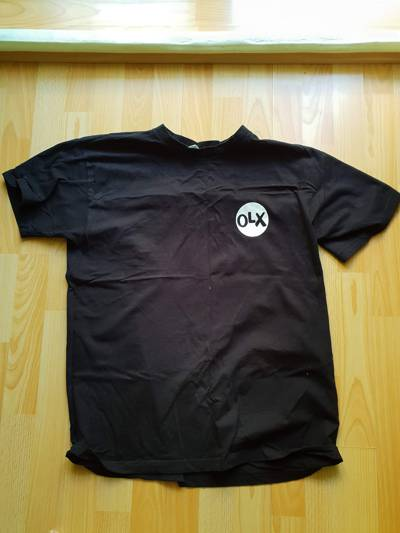

In [13]:
load_img(full_name)

In [14]:
# reduce target size for neural network
img= load_img(full_name,target_size=(299,299))

In [15]:
# convert into array
x= np.array(img)
x.shape

(299, 299, 3)

Pre-trained Convolutional Neural Network
Use a network that was already trained on some data
Imagenet dataset: https://image-net.org
Pre-trained models: https://keras.io/api/applications
We will use the Xception model

In [ ]:
# Xception is a pre-trained deep learning model made by Google.
# It is VERY good at understanding images — especially for classification.
# It has already been trained on ImageNet, a huge dataset

In [16]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [17]:
model= Xception(weights='imagenet',input_shape=(299,299,3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [18]:
# Use this model now to classify the image of the t-shirt above
# This model does not expect a single image, but a couple of images
X= np.array([x])
X.shape


(1, 299, 299, 3)

In [20]:
# Before applying the model we need to do some preprocessing
X= preprocess_input(X)

In [22]:
pred= model.predict(X)
pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


(1, 1000)

In [ ]:
# The output contains the propabilty of the image of being in a specific class
# In total there are 1000 classes
# In order to understand the output, we need to now which are the classes
# For that we use the decode_predictions function, which gives the best results

In [23]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', np.float32(0.68196267)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814007)),
  ('n04370456', 'sweatshirt', np.float32(0.03432477)),
  ('n03710637', 'maillot', np.float32(0.011354245)),
  ('n04525038', 'velvet', np.float32(0.0018453626))]]

In [ ]:
# Imagenet does not have a class "t-shirt"
# To predict the clothing classes we have, we need a different model for that
# We can use the Xceptions model and adjust it for our purpose
# We don't have to train it from scratch

8.4 Convolutional neural networks

In [ ]:
# Mainly consists of convolutional and dense layers
# A convolutional layer consists of filters (of simple shapes) and it is calculated how similar the pixels are to this filter.
# These filters produce feature maps, which go to the next layer
# In each layer the neural net can learn more complicated features
# After passing the image through the convolutional filters, we get a vector representation of the image
# This vector representation is passed through a set of dense layers, which then give the prediction
# The prediction is given as a propability
# Depending on the problem, the last layer could be a
# Sigmoid layer for binary classification
# a Softmax layer for multiple classification
# REcommended website: https://cs231n.github.io

<!-- CNN converts Image into Vector representation,then the Dense layer (dense: every I/p connected to o/p)
Dense layer is basically Matrix multiplication

 -->
 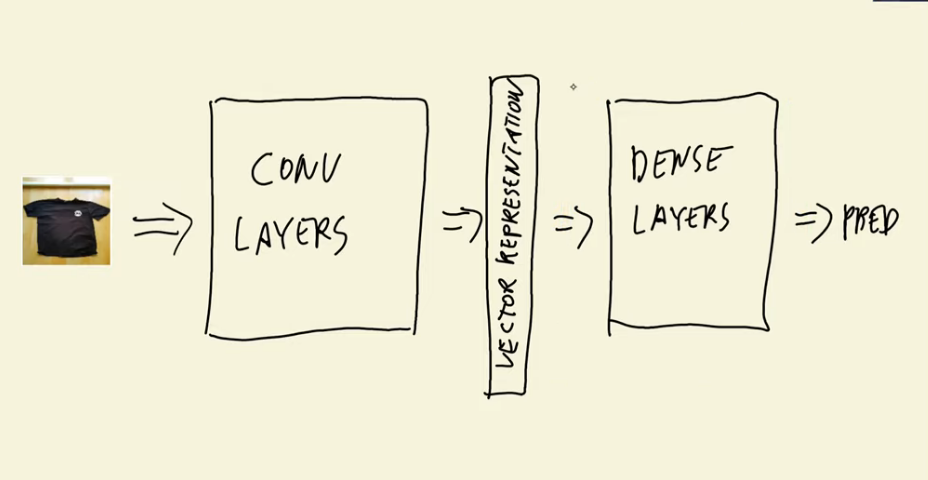

8.5 Transfer learning

In [ ]:
# Take a pre-trained CNN (Xception trained on ImageNet)
# Freeze its weights (keep learned features like edges, textures, shapes)
# Add our own classifier (10 clothing classes)
# Train only the top layers
# This is fast, requires less data, and gives good accuracy.

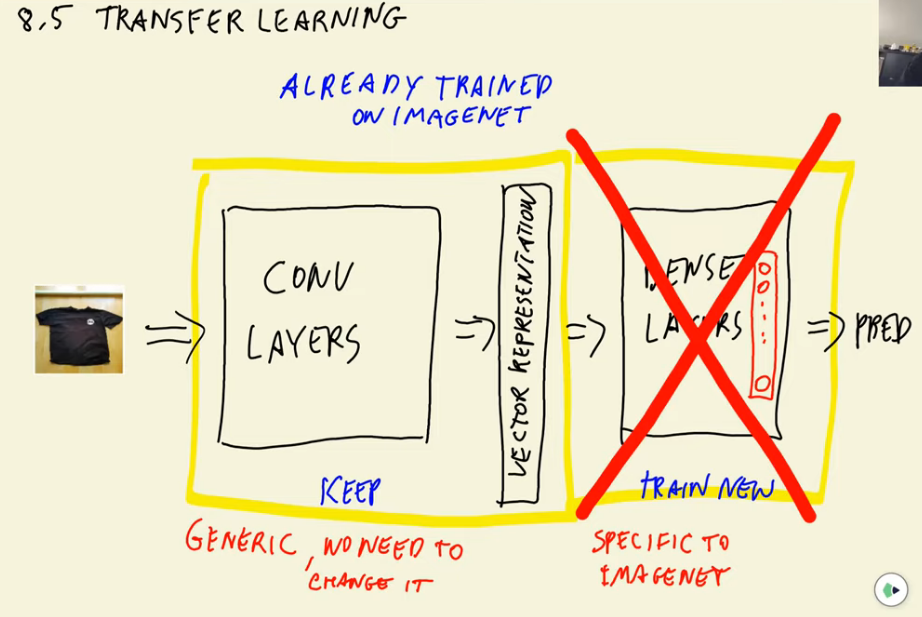

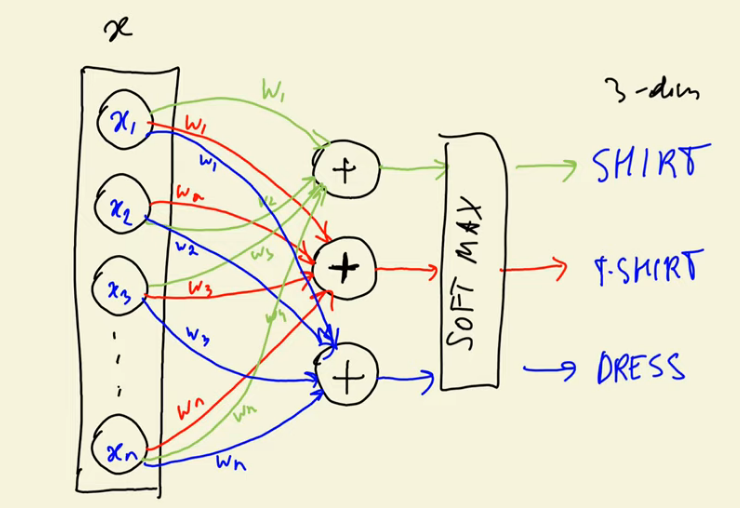

sigmoid for multiple classes= Softmax

In [ ]:
# Reading data with ImageDataGenerator
# Train Xception on smaller images (150x150)
# (Better to run it with a GPU)

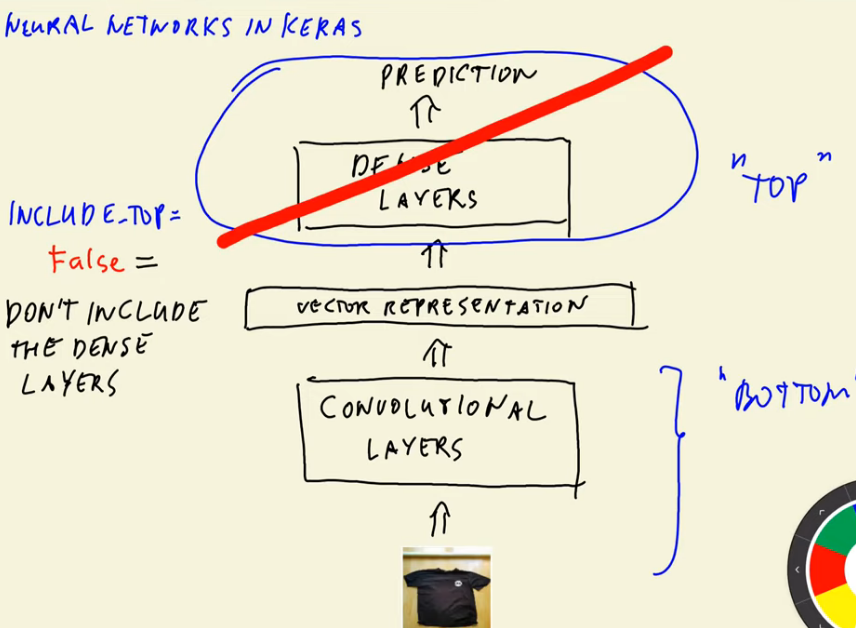

In [25]:
 # Import Libraries:loads or processes data as part of the pipeline.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_gen = ImageDataGenerator(preprocessing_function= preprocess_input)
 
train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)


Found 3068 images belonging to 10 classes.


In [26]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

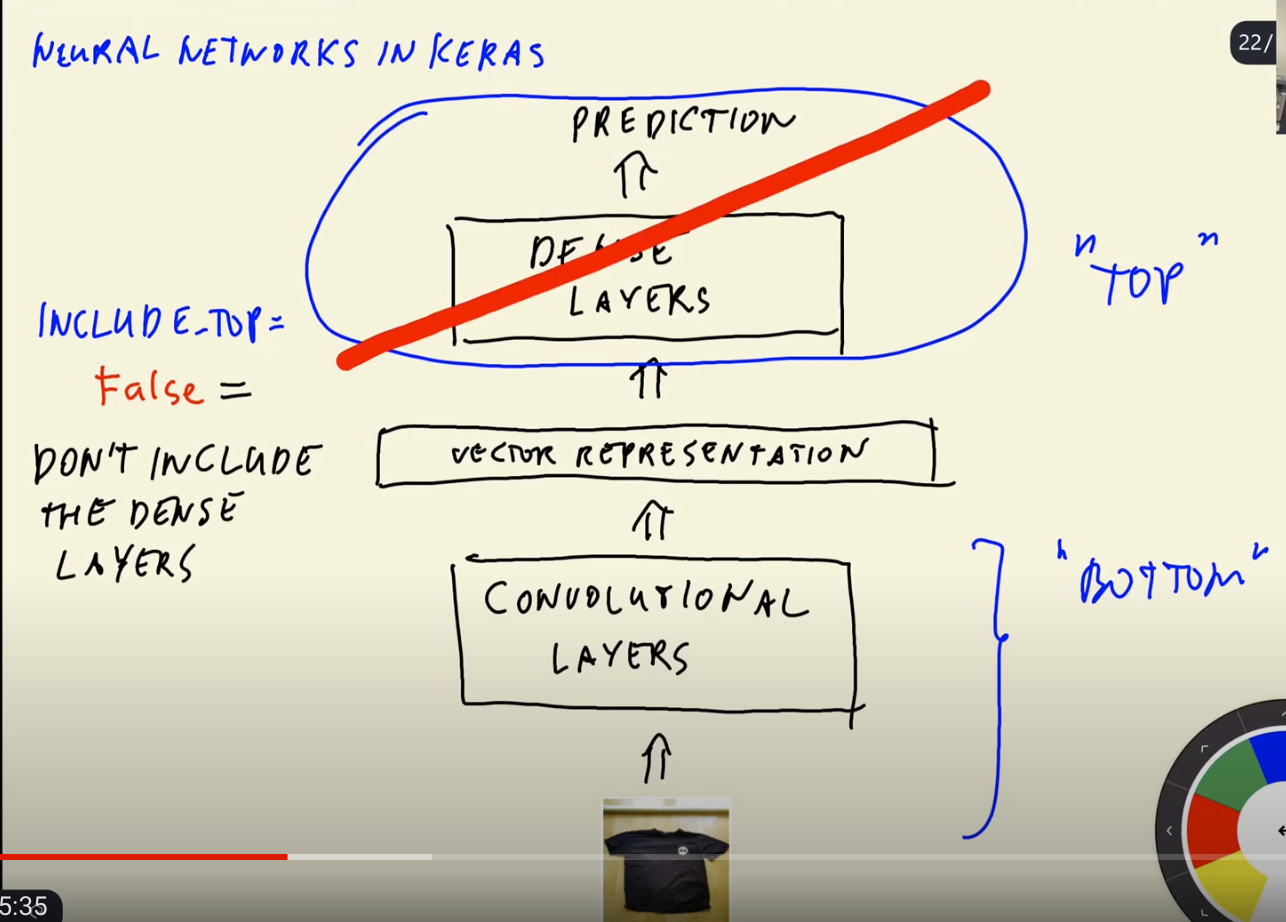

In [28]:
X,y = next(train_ds)
y[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [30]:
val_gen = ImageDataGenerator(preprocessing_function= preprocess_input)
 
val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.


In [ ]:
base_model= Xception(include_top=False,  
    weights='imagenet',
    input_shape= (150,150,3)
    
)
base_model.trainable = False



In [ ]:
# Create a new top 
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs)

outputs = base

model = keras.Model(inputs, outputs)
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [37]:
preds.shape

(32, 5, 5, 2048)

In [38]:
#Turn this output into a vector
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [39]:
preds = model.predict(X)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(32, 10)

In [40]:

# This model still has to be trained
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)


In [41]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [42]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6649 - loss: 1.3186 - val_accuracy: 0.8211 - val_loss: 0.5590
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8207 - loss: 0.5765 - val_accuracy: 0.8836 - val_loss: 0.3268
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8647 - loss: 0.4087 - val_accuracy: 0.8882 - val_loss: 0.3109
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9175 - loss: 0.2519 - val_accuracy: 0.9531 - val_loss: 0.1389
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9234 - loss: 0.2279 - val_accuracy: 0.9211 - val_loss: 0.2325
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.9573 - loss: 0.1280 - val_accuracy: 0.9602 - val_loss: 0.1090
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9694 - loss: 0.0996 - val_accuracy: 0.9726 - val_loss: 0.0758
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9811 - loss: 0.0651 - val_accuracy: 0.9948 - v

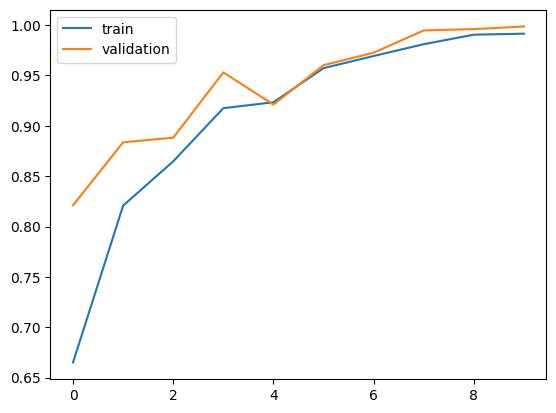

In [43]:
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="validation")
plt.legend();

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
